# Стадии сна — Блендинг бустингов (LightGBM / CatBoost / XGBoost)

**Задача.** Предсказать `sleep_stage` ∈ {0,1,2,3}. **Метрика.** macro-F1.

**План:**
1. **LightGBM** — базлайн (фиксированные разумные параметры).
2. **CatBoost** и **XGBoost** — тюним **по отдельности** (короткие сетки, чтобы быстро).
3. Сравниваем **CV-оценки** трёх моделей.
4. **Блендим вероятности** и **оптимизируем веса блендинга по кросс-валидации**.

Протокол честный: один и тот же `StratifiedKFold(5)` для всех моделей → OOF-вероятности согласованы и пригодны
для блендинга без утечки. Все три бустинга едят NaN нативно (импутация/масштабирование не нужны).
После каждой ячейки — короткий вывод.

## 0. Подготовка

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
RS = 42

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, ConfusionMatrixDisplay

train = pd.read_csv("train.csv"); test = pd.read_csv("test.csv")
ss = pd.read_csv("sample_submission.csv")
target = "sleep_stage"
features = [c for c in train.columns if c not in ("id", target)]
y = train[target].values
classes = sorted(np.unique(y)); n_class = len(classes)

CV = StratifiedKFold(5, shuffle=True, random_state=RS)   # общий для всех моделей
def mf(proba): return f1_score(y, np.asarray(proba).argmax(1), average="macro")
print("train:", train.shape, "| признаков:", len(features), "| классов:", n_class)
# Вывод: общий протокол CV задан -> OOF всех трёх моделей будут на одних фолдах и сравнимы.

train: (9000, 23) | признаков: 21 | классов: 4


## 1. Базлайн — LightGBM (без тюнинга)
Фиксируем разумные параметры; число деревьев подбирает early stopping в каждом фолде.

In [2]:
def oof_lgbm(params, seed=RS):
    oof = np.zeros((len(train), n_class)); iters = []
    p = dict(params, seed=seed)
    for tr, va in CV.split(train[features], y):
        m = lgb.train(p, lgb.Dataset(train[features].iloc[tr], y[tr]), num_boost_round=3000,
                      valid_sets=[lgb.Dataset(train[features].iloc[va], y[va])],
                      callbacks=[lgb.early_stopping(60, verbose=False), lgb.log_evaluation(0)])
        oof[va] = m.predict(train[features].iloc[va], num_iteration=m.best_iteration); iters.append(m.best_iteration)
    return oof, iters

LGB_PARAMS = dict(objective="multiclass", num_class=n_class, metric="multi_logloss",
                  learning_rate=0.03, num_leaves=15, min_child_samples=20,
                  feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=1, verbosity=-1, n_jobs=-1)
lgbm_oof, lgbm_iters = oof_lgbm(LGB_PARAMS)
print(f"LightGBM (базлайн) CV macro-F1 = {mf(lgbm_oof):.4f}")
# Вывод: зафиксирован базлайн LightGBM -> точка отсчёта для CatBoost и XGBoost.

LightGBM (базлайн) CV macro-F1 = 0.8254


## 2. Тюнинг XGBoost (короткая сетка)
Сканируем только `max_depth` × `eta` — 4 конфигурации, число деревьев через early stopping.

In [3]:
def oof_xgb(params, seed=RS):
    oof = np.zeros((len(train), n_class)); iters = []
    p = dict(params, seed=seed)
    for tr, va in CV.split(train[features], y):
        dtr = xgb.DMatrix(train[features].iloc[tr], label=y[tr])
        dva = xgb.DMatrix(train[features].iloc[va], label=y[va])
        bst = xgb.train(p, dtr, num_boost_round=3000, evals=[(dva, "v")],
                        early_stopping_rounds=60, verbose_eval=False)
        oof[va] = bst.predict(dva, iteration_range=(0, bst.best_iteration + 1)); iters.append(bst.best_iteration)
    return oof, iters

XGB_BASE = dict(objective="multi:softprob", num_class=n_class, eval_metric="mlogloss",
                eta=0.05, subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
                tree_method="hist", verbosity=0)
rows = []
for d in [4, 6]:
    for eta in [0.03, 0.05]:
        p = dict(XGB_BASE, max_depth=d, eta=eta)
        rows.append({"max_depth": d, "eta": eta, "CV_macroF1": mf(oof_xgb(p)[0])})
xgb_res = pd.DataFrame(rows).sort_values("CV_macroF1", ascending=False).reset_index(drop=True)
print(xgb_res.round(4).to_string(index=False))
bx = xgb_res.iloc[0]
XGB_BEST = dict(XGB_BASE, max_depth=int(bx.max_depth), eta=float(bx.eta))
xgb_oof, xgb_iters = oof_xgb(XGB_BEST)
print(f"\nЛучший XGBoost CV macro-F1 = {mf(xgb_oof):.4f}  @ {dict(max_depth=int(bx.max_depth), eta=float(bx.eta))}")
# Вывод: выбрана лучшая по CV конфигурация XGBoost.

 max_depth  eta  CV_macroF1
         6 0.03      0.8232
         4 0.03      0.8229
         4 0.05      0.8214
         6 0.05      0.8211

Лучший XGBoost CV macro-F1 = 0.8232  @ {'max_depth': 6, 'eta': 0.03}


## 3. Тюнинг CatBoost (короткая сетка)
Сканируем `depth` × `learning_rate` — 4 конфигурации, итерации ограничены + early stopping (быстро).

In [4]:
def oof_cat(depth, lr, seed=RS):
    oof = np.zeros((len(train), n_class)); iters = []
    for tr, va in CV.split(train[features], y):
        m = CatBoostClassifier(iterations=800, depth=depth, learning_rate=lr,
                               loss_function="MultiClass", random_seed=seed,
                               early_stopping_rounds=40, verbose=0, allow_writing_files=False)
        m.fit(train[features].iloc[tr], y[tr], eval_set=(train[features].iloc[va], y[va]), use_best_model=True)
        oof[va] = m.predict_proba(train[features].iloc[va]); iters.append(m.get_best_iteration())
    return oof, iters

rows = []
for d in [4, 6]:
    for lr in [0.03, 0.06]:
        rows.append({"depth": d, "lr": lr, "CV_macroF1": mf(oof_cat(d, lr)[0])})
cat_res = pd.DataFrame(rows).sort_values("CV_macroF1", ascending=False).reset_index(drop=True)
print(cat_res.round(4).to_string(index=False))
bc = cat_res.iloc[0]
cat_oof, cat_iters = oof_cat(int(bc.depth), float(bc.lr))
print(f"\nЛучший CatBoost CV macro-F1 = {mf(cat_oof):.4f}  @ {dict(depth=int(bc.depth), lr=float(bc.lr))}")
# Вывод: выбрана лучшая по CV конфигурация CatBoost.

 depth   lr  CV_macroF1
     6 0.06      0.8254
     4 0.06      0.8181
     6 0.03      0.8178
     4 0.03      0.8104

Лучший CatBoost CV macro-F1 = 0.8254  @ {'depth': 6, 'lr': 0.06}


## 4. Сравнение CV-оценок

In [5]:
cmp = pd.DataFrame({
    "модель": ["LightGBM (базлайн)", "XGBoost (тюнинг)", "CatBoost (тюнинг)"],
    "CV_macroF1": [mf(lgbm_oof), mf(xgb_oof), mf(cat_oof)],
}).sort_values("CV_macroF1", ascending=False)
print(cmp.round(4).to_string(index=False))
print("\nДля справки: одиночный RBF-SVM ≈ 0.834 (LB 0.8415)")
# Вывод: видно ранжирование трёх бустингов по честной CV; обычно они идут вровень и ниже SVM.

            модель  CV_macroF1
 CatBoost (тюнинг)      0.8254
LightGBM (базлайн)      0.8254
  XGBoost (тюнинг)      0.8232

Для справки: одиночный RBF-SVM ≈ 0.834 (LB 0.8415)


## 5. Разнородность моделей
Блендинг помогает только если модели ошибаются по-разному. Смотрим попарные расхождения предсказаний.

In [6]:
preds = {"LGB": lgbm_oof.argmax(1), "XGB": xgb_oof.argmax(1), "CAT": cat_oof.argmax(1)}
import itertools
for a, b in itertools.combinations(preds, 2):
    print(f"расхождение {a} vs {b} = {(preds[a]!=preds[b]).mean():.3f}")
# Вывод: чем выше расхождение, тем больше шанс, что блендинг что-то добавит сверх лучшей одиночной модели.

расхождение LGB vs XGB = 0.039
расхождение LGB vs CAT = 0.065
расхождение XGB vs CAT = 0.065


## 6. Блендинг + оптимизация весов по кросс-валидации
Перебираем веса `(w_lgb, w_xgb, w_cat)` на симплексе (сумма=1) и берём максимум CV macro-F1 на OOF-вероятностях.
Это и есть оптимизация весов блендинга по кросс-валидации.

In [7]:
oofs = [lgbm_oof, xgb_oof, cat_oof]
grid = np.arange(0, 1.0001, 0.05)
best = (-1, None)
for wl in grid:
    for wx in grid:
        wc = 1 - wl - wx
        if wc < -1e-9: continue
        s = mf(wl*oofs[0] + wx*oofs[1] + wc*oofs[2])
        if s > best[0]: best = (s, (round(wl,2), round(wx,2), round(wc,2)))
blend_f1, (WL, WX, WC) = best
print(f"лучшие веса (LGB, XGB, CAT) = ({WL}, {WX}, {WC})")
print(f"CV macro-F1 блендинга       = {blend_f1:.4f}")
print(f"  лучшая одиночная          = {max(mf(o) for o in oofs):.4f}")
print(f"  равные веса (1/3 каждая)  = {mf(sum(oofs)/3):.4f}")
# Вывод: оптимизированный по CV блендинг сравниваем с лучшей одиночной и с равными весами -> виден реальный вклад.

лучшие веса (LGB, XGB, CAT) = (0.2, 0.25, 0.55)
CV macro-F1 блендинга       = 0.8291
  лучшая одиночная          = 0.8254
  равные веса (1/3 каждая)  = 0.8267


## 7. Анализ ошибок блендинга

              precision    recall  f1-score   support

           0      0.857     0.848     0.852      2001
           1      0.843     0.858     0.851      2442
           2      0.785     0.772     0.778      2237
           3      0.833     0.838     0.835      2320

    accuracy                          0.829      9000
   macro avg      0.829     0.829     0.829      9000
weighted avg      0.829     0.829     0.829      9000



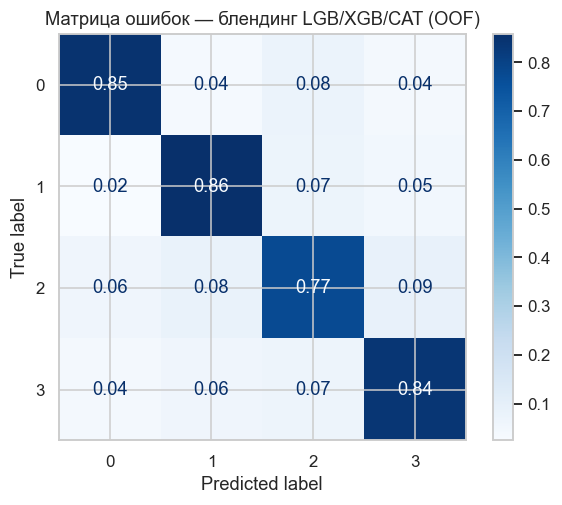

In [8]:
blend_oof = WL*oofs[0] + WX*oofs[1] + WC*oofs[2]
pred_oof = blend_oof.argmax(1)
print(classification_report(y, pred_oof, digits=3))
ConfusionMatrixDisplay.from_predictions(y, pred_oof, normalize="true",
                                        display_labels=classes, cmap="Blues", values_format=".2f")
plt.title("Матрица ошибок — блендинг LGB/XGB/CAT (OOF)"); plt.show()
# Вывод: класс 2 ожидаемо остаётся самым трудным; смотрим, подтянул ли блендинг его recall.

## 8. Финальная модель и сабмит
Переобучаем все три модели на полном train и блендим их test-вероятности с найденными весами.

In [9]:
# LightGBM на полном train
lgb_full = lgb.train(LGB_PARAMS, lgb.Dataset(train[features], y), num_boost_round=int(np.mean(lgbm_iters)))
lgb_te = lgb_full.predict(test[features])
# XGBoost на полном train
xgb_full = xgb.train(XGB_BEST, xgb.DMatrix(train[features], label=y), num_boost_round=int(np.mean(xgb_iters)))
xgb_te = xgb_full.predict(xgb.DMatrix(test[features]))
# CatBoost на полном train
cat_full = CatBoostClassifier(iterations=int(np.mean(cat_iters)), depth=int(bc.depth), learning_rate=float(bc.lr),
                              loss_function="MultiClass", random_seed=RS, verbose=0, allow_writing_files=False)
cat_full.fit(train[features], y)
cat_te = cat_full.predict_proba(test[features])

blend_te = WL*lgb_te + WX*xgb_te + WC*cat_te
pred_te = blend_te.argmax(1)
submission = pd.DataFrame({"id": test["id"], target: pred_te})[ss.columns]
submission.to_csv("submission_blend3.csv", index=False)
print(f"CV macro-F1 блендинга = {blend_f1:.4f}")
print("Сохранено submission_blend3.csv:", submission.shape)
print(pd.DataFrame({"train": pd.Series(y).value_counts(normalize=True).sort_index(),
                    "test_pred": pd.Series(pred_te).value_counts(normalize=True).sort_index()}).round(3))
submission.head()
# Вывод: финальный сабмит — взвешенный блендинг трёх бустингов, веса подобраны по CV; распределение близко к train.

CV macro-F1 блендинга = 0.8291
Сохранено submission_blend3.csv: (5000, 2)
   train  test_pred
0  0.222      0.224
1  0.271      0.260
2  0.249      0.255
3  0.258      0.261


,id,sleep_stage
0,9000,0
1,9001,3
2,9002,1
3,9003,2
4,9004,3


## 9. Итоги
- **LightGBM** взят базлайном, **XGBoost и CatBoost** оттюнены короткими сетками (быстро).
- **CV-сравнение** (раздел 4) показывает ранжирование моделей честно по OOF.
- **Веса блендинга оптимизированы по кросс-валидации** на симплексе (раздел 6).
- **Оговорка:** веса подобраны на тех же OOF, что и оцениваются → лёгкий оптимизм; на новых данных эффект чуть меньше.
- **Контекст:** три бустинга — одно семейство и сильно скоррелированы, поэтому блендинг даёт малый прирост;
  по прошлому опыту LB этой задачи одиночный RBF-SVM (0.8415) остаётся самым надёжным.